In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [3]:
data = pd.read_csv("netflix_titles.csv")

In [4]:
data.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [5]:
data.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


In [6]:
data.shape

(8807, 12)

In [7]:
data.size

105684

In [8]:
data.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [9]:
data.dtypes

show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [11]:
data["director"].fillna("Unknown", inplace=True)

In [12]:
data["cast"].fillna("Not Available", inplace=True)

In [13]:
data["country"].fillna(data["country"].mode()[0], inplace=True)

In [14]:
data.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           4
duration         3
listed_in        0
description      0
dtype: int64

In [15]:
data['date_added'] = data['date_added'].fillna(
    data['release_year'].astype(str) + '-01-01'
)

data['date_added'] = pd.to_datetime(data['date_added'], format='mixed')

In [16]:
data["year_added"] = data["date_added"].dt.year
data["month_added"] = data["date_added"].dt.month

In [17]:
data['date_added'].isnull().sum()

np.int64(0)

In [18]:
data['rating'].mode()

0    TV-MA
Name: rating, dtype: object

In [19]:
data['rating'].fillna(data['rating'].mode()[0], inplace=True)

In [20]:
data['duration_num'] = data['duration'].str.extract('(\d+)')

In [21]:
data['duration_num'] = pd.to_numeric(data['duration_num'])

In [22]:
data['duration_num'].fillna(data['duration_num'].median(), inplace=True)

In [23]:
data.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        3
listed_in       0
description     0
year_added      0
month_added     0
duration_num    0
dtype: int64

In [24]:
data['duration_type'] = data['duration'].str.extract('([A-Za-z]+)')
data['duration_type'].fillna("min", inplace=True)

In [25]:
data.drop("duration", axis=1, inplace=True)

In [26]:
data.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'listed_in', 'description', 'year_added',
       'month_added', 'duration_num', 'duration_type'],
      dtype='object')

In [27]:
data["main_genre"] = data["listed_in"].str.split(",").str[0]

In [28]:
data.duplicated().sum()

np.int64(0)

In [29]:
#Feature Enginering
data["movie_duration_min"] = np.where(data["duration_type"]=="min", data["duration_num"], np.nan)

In [30]:
data["tv_seasons"] = np.where(data["duration_type"]=="Season", data["duration_num"], np.nan)

In [31]:
data["content_age"] = data["year_added"] - data["release_year"]

In [32]:
data["country_count"] = data["country"].str.count(",") + 1

In [33]:
data["cast_count"] = data["cast"].apply(lambda x: 0 if x=="Not Available" else len(x.split(",")))

In [34]:
data["director_known"] = np.where(data["director"]=="Unknown", 0, 1)

In [35]:
data["is_movie"] = np.where(data["type"]=="Movie",1,0)

statstical analysis

In [36]:
data.describe()

,date_added,release_year,year_added,month_added,duration_num,movie_duration_min,tv_seasons,content_age,country_count,cast_count,director_known,is_movie
count,8807,8807.000000,8807.000000,8807.000000,8807.000000,6131.000000,1793.0,8807.000000,8807.000000,8807.000000,8807.000000,8807.000000
mean,2019-05-13 21:37:54.781423872,2014.180198,2018.863291,6.648575,69.853071,99.571522,1.0,4.683093,1.231975,7.281254,0.700920,0.696151
min,2003-01-01 00:00:00,1925.000000,2003.000000,1.000000,1.000000,3.000000,1.0,-3.000000,1.000000,0.000000,0.000000,0.000000
25%,2018-04-03 00:00:00,2013.000000,2018.000000,4.000000,2.000000,87.000000,1.0,0.000000,1.000000,4.000000,0.000000,0.000000
50%,2019-07-01 00:00:00,2017.000000,2019.000000,7.000000,88.000000,98.000000,1.0,1.000000,1.000000,8.000000,1.000000,1.000000
75%,2020-08-18 00:00:00,2019.000000,2020.000000,10.000000,106.000000,114.000000,1.0,5.000000,1.000000,10.000000,1.000000,1.000000
max,2021-09-25 00:00:00,2021.000000,2021.000000,12.000000,312.000000,312.000000,1.0,93.000000,12.000000,50.000000,1.000000,1.000000
std,NaN,8.819312,1.602696,3.439879,50.807276,28.284829,0.0,8.783427,0.668818,4.862244,0.457881,0.459944


EDA

In [37]:
data["year_added"].value_counts().sort_index()

year_added
2003       2
2008       3
2009       2
2010       2
2011      13
2012       4
2013      12
2014      24
2015      84
2016     430
2017    1188
2018    1650
2019    2016
2020    1879
2021    1498
Name: count, dtype: int64

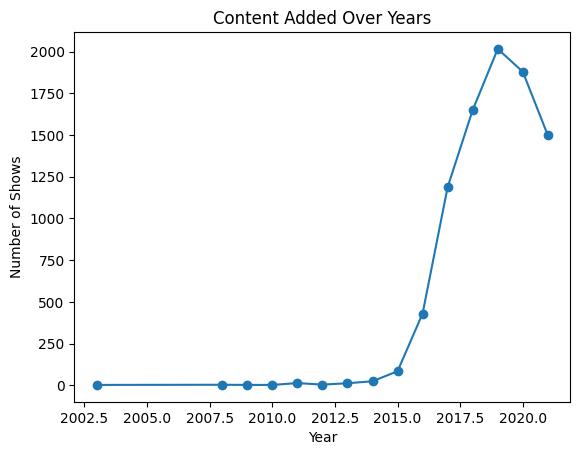

In [38]:
data["year_added"].value_counts().sort_index().plot(kind="line", marker="o")
plt.title("Content Added Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Shows")
plt.show()

Insights: Netflix growth trend

In [39]:
data["country"].value_counts().head(10)

country
United States     3649
India              972
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64

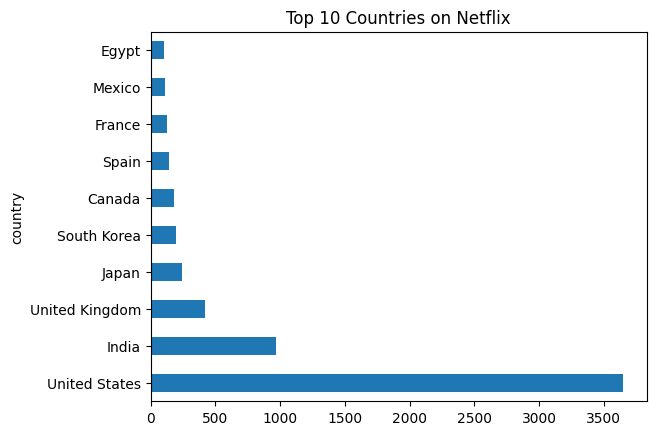

In [40]:
data["country"].value_counts().head(10).plot(kind="barh")
plt.title("Top 10 Countries on Netflix")
plt.show()

👉 Insight:

Which country dominates Netflix 🌍
netflix

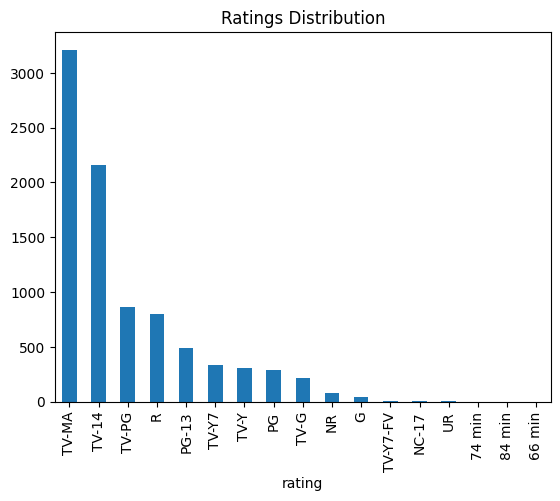

In [41]:
data["rating"].value_counts().plot(kind="bar")
plt.title("Ratings Distribution")
plt.show()

Is Netflix family-friendly or adult-focused?
adult fouced

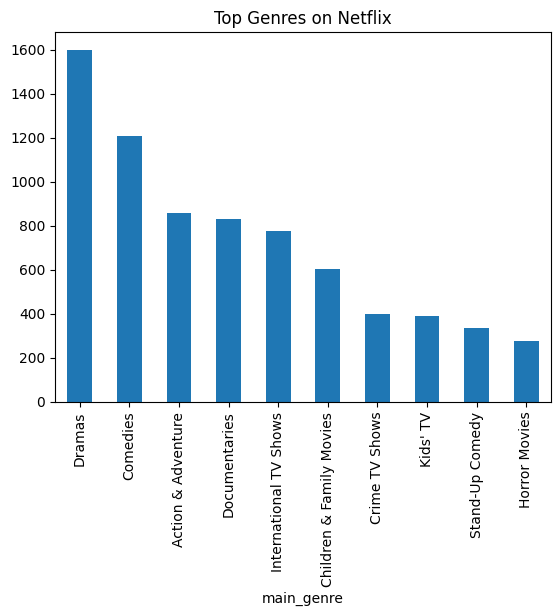

In [42]:
data["main_genre"].value_counts().head(10).plot(kind="bar")
plt.title("Top Genres on Netflix")
plt.show()

👉 Insight:

Which genre Netflix loves most : comadies and dramas

In [43]:
data["movie_duration_min"].describe()

count    6131.000000
mean       99.571522
std        28.284829
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: movie_duration_min, dtype: float64

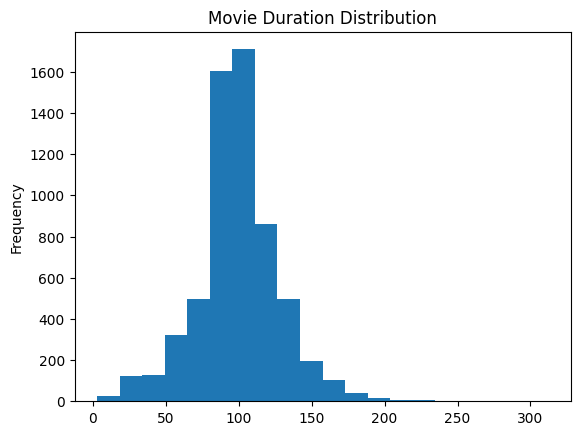

In [44]:
data["movie_duration_min"].dropna().plot(kind="hist", bins=20)
plt.title("Movie Duration Distribution")
plt.show()

In [45]:
data["tv_seasons"].describe()

count    1793.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
Name: tv_seasons, dtype: float64

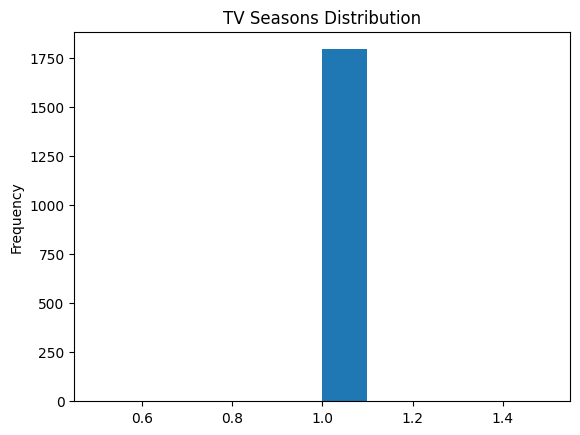

In [46]:
data["tv_seasons"].dropna().plot(kind="hist", bins=10)
plt.title("TV Seasons Distribution")
plt.show()

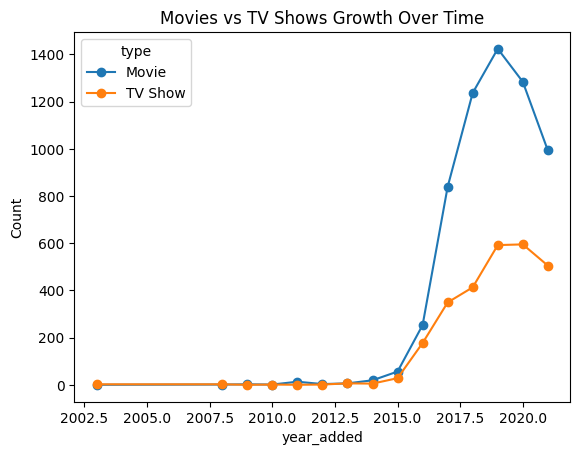

In [47]:
pd.crosstab(data["year_added"], data["type"]).plot(kind="line", marker="o")
plt.title("Movies vs TV Shows Growth Over Time")
plt.ylabel("Count")
plt.show()

👉 Insight:

Netflix shifting from Movies → TV Shows?

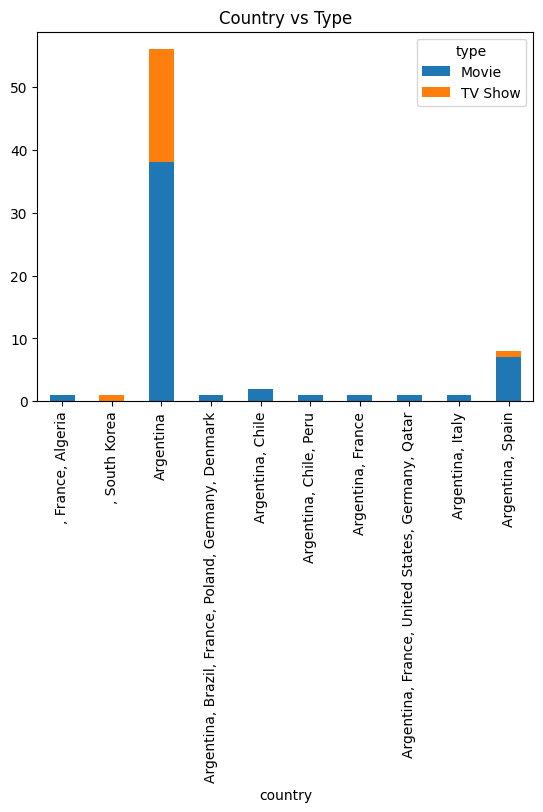

In [48]:
pd.crosstab(data["country"], data["type"]).head(10).plot(kind="bar", stacked=True)
plt.title("Country vs Type")
plt.show()

👉 Insight:

Which country makes more movies vs shows?

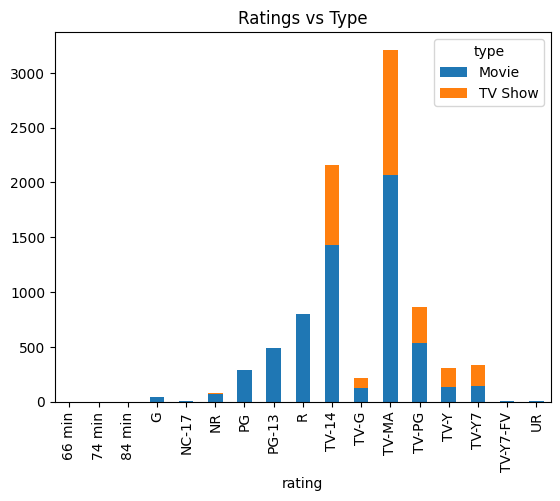

In [49]:
pd.crosstab(data["rating"], data["type"]).plot(kind="bar", stacked=True)
plt.title("Ratings vs Type")
plt.show()

👉 Insight:

Are TV shows more adult (TV-MA)?

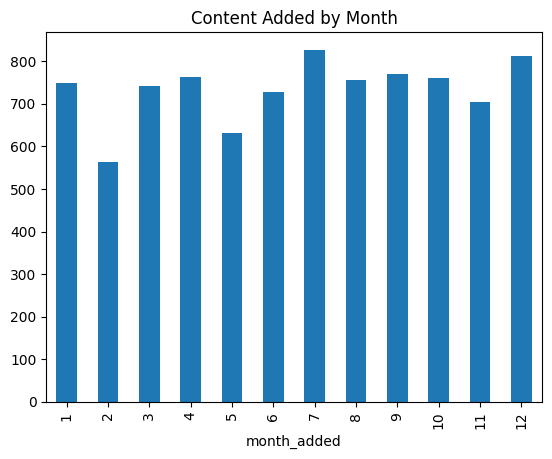

In [50]:
data["month_added"].value_counts().sort_index().plot(kind="bar")
plt.title("Content Added by Month")
plt.show()

👉 Insight:

Which months Netflix releases most content

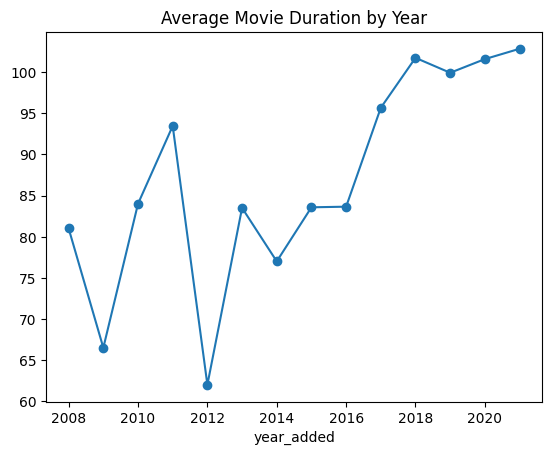

In [51]:
data.groupby("year_added")["movie_duration_min"].mean().plot(marker="o")
plt.title("Average Movie Duration by Year")
plt.show()

👉 Insight:

Movies getting longer or shorter?

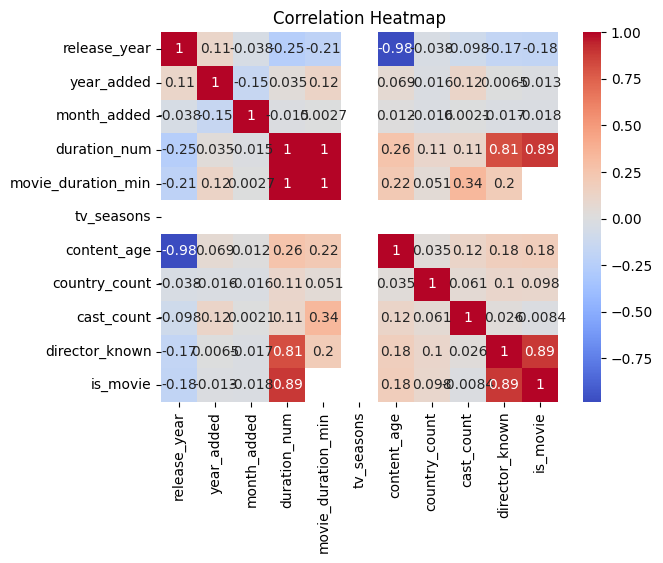

In [52]:
import seaborn as sns

corr = data.select_dtypes(include=np.number).corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

👉 Insight:

Relationship between engineered features

OUTLIERS

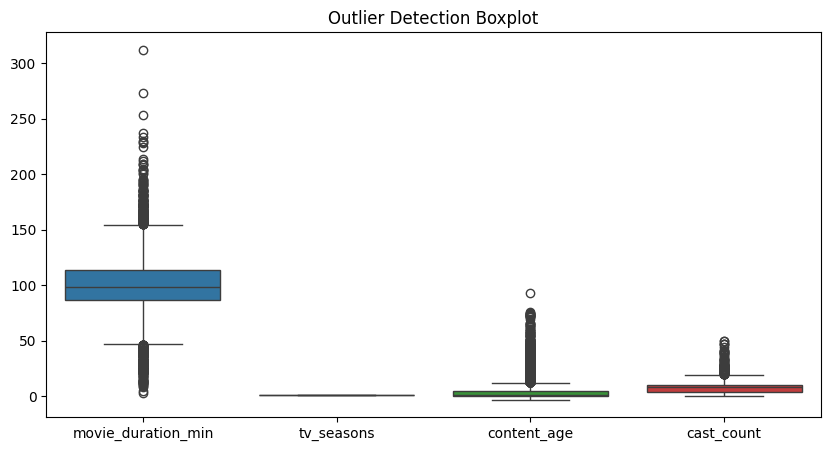

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.boxplot(data=data[["movie_duration_min","tv_seasons","content_age","cast_count"]])
plt.title("Outlier Detection Boxplot")
plt.show()

In [54]:
def detect_outliers(col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = data[(data[col] < lower) | (data[col] > upper)]
    
    print(col, "outliers count:", len(outliers))

In [55]:
for col in ["movie_duration_min","tv_seasons","content_age","cast_count"]:
    detect_outliers(col)

movie_duration_min outliers count: 450
tv_seasons outliers count: 0
content_age outliers count: 972
cast_count outliers count: 123


In [56]:
def cap_outliers(col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    data[col] = np.where(data[col] > upper, upper, data[col])
    data[col] = np.where(data[col] < lower, lower, data[col])

In [57]:
for col in ["movie_duration_min","tv_seasons","content_age","cast_count"]:
    cap_outliers(col)

In [58]:
for col in ["movie_duration_min","tv_seasons","content_age","cast_count"]:
    detect_outliers(col)

movie_duration_min outliers count: 0
tv_seasons outliers count: 0
content_age outliers count: 0
cast_count outliers count: 0


In [59]:
data.describe()

,date_added,release_year,year_added,month_added,duration_num,movie_duration_min,tv_seasons,content_age,country_count,cast_count,director_known,is_movie
count,8807,8807.000000,8807.000000,8807.000000,8807.000000,6131.000000,1793.0,8807.000000,8807.000000,8807.000000,8807.000000,8807.000000
mean,2019-05-13 21:37:54.781423872,2014.180198,2018.863291,6.648575,69.853071,99.573316,1.0,3.309527,1.231975,7.180084,0.700920,0.696151
min,2003-01-01 00:00:00,1925.000000,2003.000000,1.000000,1.000000,46.500000,1.0,-3.000000,1.000000,0.000000,0.000000,0.000000
25%,2018-04-03 00:00:00,2013.000000,2018.000000,4.000000,2.000000,87.000000,1.0,0.000000,1.000000,4.000000,0.000000,0.000000
50%,2019-07-01 00:00:00,2017.000000,2019.000000,7.000000,88.000000,98.000000,1.0,1.000000,1.000000,8.000000,1.000000,1.000000
75%,2020-08-18 00:00:00,2019.000000,2020.000000,10.000000,106.000000,114.000000,1.0,5.000000,1.000000,10.000000,1.000000,1.000000
max,2021-09-25 00:00:00,2021.000000,2021.000000,12.000000,312.000000,154.500000,1.0,12.500000,12.000000,19.000000,1.000000,1.000000
std,NaN,8.819312,1.602696,3.439879,50.807276,25.012497,0.0,4.311845,0.668818,4.444351,0.457881,0.459944


In [60]:
data["movie_duration_min"].describe()

count    6131.000000
mean       99.573316
std        25.012497
min        46.500000
25%        87.000000
50%        98.000000
75%       114.000000
max       154.500000
Name: movie_duration_min, dtype: float64

In [61]:
data["movie_duration_min"].mean()
data["movie_duration_min"].median()
data["movie_duration_min"].std()

np.float64(25.0124970216343)

In [62]:
data["tv_seasons"].describe()

count    1793.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
Name: tv_seasons, dtype: float64

In [63]:
data["content_age"].describe()

count    8807.000000
mean        3.309527
std         4.311845
min        -3.000000
25%         0.000000
50%         1.000000
75%         5.000000
max        12.500000
Name: content_age, dtype: float64

In [64]:
data["content_age"].mean()

np.float64(3.309526513001022)

In [65]:
data["cast_count"].describe()

count    8807.000000
mean        7.180084
std         4.444351
min         0.000000
25%         4.000000
50%         8.000000
75%        10.000000
max        19.000000
Name: cast_count, dtype: float64

In [66]:
data.groupby("type")[["movie_duration_min","tv_seasons","content_age"]].mean()

,movie_duration_min,tv_seasons,content_age
type,,,
Movie,99.573316,NaN,3.917469
TV Show,NaN,1.0,1.916667


In [67]:
data.corr(numeric_only=True)

,release_year,year_added,month_added,duration_num,movie_duration_min,tv_seasons,content_age,country_count,cast_count,director_known,is_movie
release_year,1.000000,0.113208,-0.038500,-0.249174,-0.192870,NaN,-0.802222,-0.037833,-0.110128,-0.173518,-0.181710
year_added,0.113208,1.000000,-0.148432,0.035283,0.131045,NaN,0.102838,-0.015648,0.128687,0.006485,-0.013223
month_added,-0.038500,-0.148432,1.000000,-0.014886,0.008051,NaN,-0.020749,-0.015501,0.002461,-0.017207,-0.017830
duration_num,-0.249174,0.035283,-0.014886,1.000000,0.978838,NaN,0.302591,0.108597,0.136841,0.814722,0.885416
movie_duration_min,-0.192870,0.131045,0.008051,0.978838,1.000000,NaN,0.271435,0.052117,0.376063,0.201078,NaN
tv_seasons,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
content_age,-0.802222,0.102838,-0.020749,0.302591,0.271435,NaN,1.000000,0.074291,0.204460,0.208003,0.213426
country_count,-0.037833,-0.015648,-0.015501,0.108597,0.052117,NaN,0.074291,1.000000,0.066974,0.101983,0.098108
cast_count,-0.110128,0.128687,0.002461,0.136841,0.376063,NaN,0.204460,0.066974,1.000000,0.048177,0.010105
director_known,-0.173518,0.006485,-0.017207,0.814722,0.201078,NaN,0.208003,0.101983,0.048177,1.000000,0.887368


<Axes: >

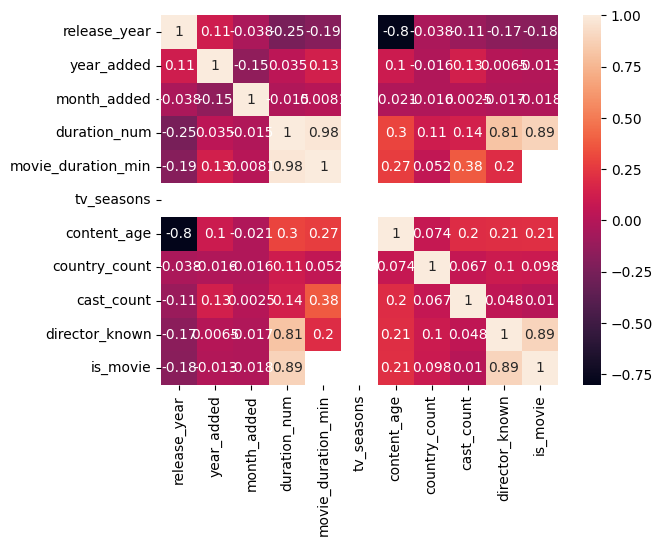

In [68]:
import seaborn as sns
sns.heatmap(data.corr(numeric_only=True), annot=True)

Q1 — Does Netflix prefer recent content?

In [69]:
data["content_age"].mean()

np.float64(3.309526513001022)

Q2 — Movie vs TV Show ratio

In [70]:
data["type"].value_counts(normalize=True)*100

type
Movie      69.615079
TV Show    30.384921
Name: proportion, dtype: float64

Q3 — Which year added most content?

In [71]:
data["year_added"].mode()

0    2019
Name: year_added, dtype: int32

In [72]:
data.to_csv("netflix_cleaned_final.csv", index=False)

In [73]:
data.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'listed_in', 'description', 'year_added',
       'month_added', 'duration_num', 'duration_type', 'main_genre',
       'movie_duration_min', 'tv_seasons', 'content_age', 'country_count',
       'cast_count', 'director_known', 'is_movie'],
      dtype='object')